In [2]:
# save sub-wise estimates to df in '/Users/mrenke/data/ds-stressrisk/interim_sum_data'
# 1. (risky-)prior-mu
# 2. evidence

# compare to objective prior, does the prior become more accurate?
# moved extraction of subwise params to get_param-estim_NLCmodel.ipynb


import arviz as az
import os.path as op
from utils import get_data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

bids_folder = '/Users/mrenke/data/ds-stressrisk'

model_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data().set_index('group', append=True)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)

objective_risky_mu = np.log(df.groupby(['subject'])['n_risky'].mean())

n_model = 1
idata= az.from_netcdf(op.join(model_folder, f'model-{n_model}_trace.netcdf'))


In [3]:
risky_prior_mu_post = idata.posterior['risky_prior_mu'].to_dataframe()
risky_prior_mu_post = risky_prior_mu_post.join(group_mapping).set_index('group', append=True)

In [4]:
import seaborn as sns
prior_mu_ses1_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group0 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors')
prior_mu_ses1_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors')
prior_mu_ses2_group1 = risky_prior_mu_post.xs('Intercept', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('group', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session', 0, 'risky_prior_mu_regressors') + risky_prior_mu_post.xs('session:group', 0, 'risky_prior_mu_regressors')

prior_mu_ses1_group0 = prior_mu_ses1_group0.xs(0, 0, 'group')
prior_mu_ses2_group0 = prior_mu_ses2_group0.xs(0, 0, 'group')

prior_mu_ses1_group1 = prior_mu_ses1_group1.xs(1, 0, 'group')
prior_mu_ses2_group1 = prior_mu_ses2_group1.xs(1, 0, 'group')
#prior_mu_ses2_group1.join(group_mapping).set_index('group', append=True)



In [5]:
# save subwise_change_risky_prior 
import pandas as pd
df_change_risky_prior_gr0 = (prior_mu_ses2_group0 - prior_mu_ses1_group0).groupby(['subject']).mean()
df_change_risky_prior_gr1 = (prior_mu_ses2_group1 - prior_mu_ses1_group1).groupby(['subject']).mean()
df_change_risky_prior = pd.concat([df_change_risky_prior_gr0, df_change_risky_prior_gr1], axis=0)
df_change_risky_prior.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior.csv')


In [6]:
diff_objective_subjective_ses1_group0 = prior_mu_ses1_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group0 = prior_mu_ses2_group0['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses1_group1 = prior_mu_ses1_group1['risky_prior_mu'] - objective_risky_mu
diff_objective_subjective_ses2_group1 = prior_mu_ses2_group1['risky_prior_mu'] - objective_risky_mu


In [ ]:
sns.distplot(diff_objective_subjective_ses1_group0)
sns.distplot(diff_objective_subjective_ses2_group0)
plt.title('group: control')
plt.legend(['session 1', 'session 2'])
plt.figure()
sns.distplot(diff_objective_subjective_ses1_group1)
sns.distplot(diff_objective_subjective_ses2_group1)
plt.title('group: stress')
plt.legend(['session 1', 'session 2'])

In [8]:
diff_objective_subjective_ses1_group0 = pd.DataFrame(diff_objective_subjective_ses1_group0)
diff_objective_subjective_ses1_group0['session'] = 1
diff_objective_subjective_ses1_group0['group'] = 0

diff_objective_subjective_ses2_group0 = pd.DataFrame(diff_objective_subjective_ses2_group0)
diff_objective_subjective_ses2_group0['session'] = 2
diff_objective_subjective_ses2_group0['group'] = 0

diff_objective_subjective_ses1_group1 = pd.DataFrame(diff_objective_subjective_ses1_group1)
diff_objective_subjective_ses1_group1['session'] = 1
diff_objective_subjective_ses1_group1['group'] = 1

diff_objective_subjective_ses2_group1 = pd.DataFrame(diff_objective_subjective_ses2_group1)
diff_objective_subjective_ses2_group1['session'] = 2
diff_objective_subjective_ses2_group1['group'] = 1

diff_objective_subjective_group1 = pd.concat([diff_objective_subjective_ses2_group1.set_index(['group','session'], append=True), diff_objective_subjective_ses1_group1.set_index(['group','session'], append=True)],axis=0)
diff_objective_subjective_group0 = pd.concat([diff_objective_subjective_ses2_group0.set_index(['group','session'], append=True), diff_objective_subjective_ses1_group0.set_index(['group','session'], append=True)],axis=0)
diff_objective_subjective = pd.concat([diff_objective_subjective_group0 , diff_objective_subjective_group1],axis=0)

diff_objective_subjective = diff_objective_subjective.rename(mapper={0:'diff_risky_obj_prior'},axis=1)

In [14]:
tmp = diff_objective_subjective.xs(1, 0, 'group')['diff_risky_obj_prior'] - diff_objective_subjective.xs(0, 0, 'group')['diff_risky_obj_prior']

In [24]:
tmp = diff_objective_subjective.xs(1, 0, 'group').values - diff_objective_subjective.xs(0, 0, 'group').values

0.333705


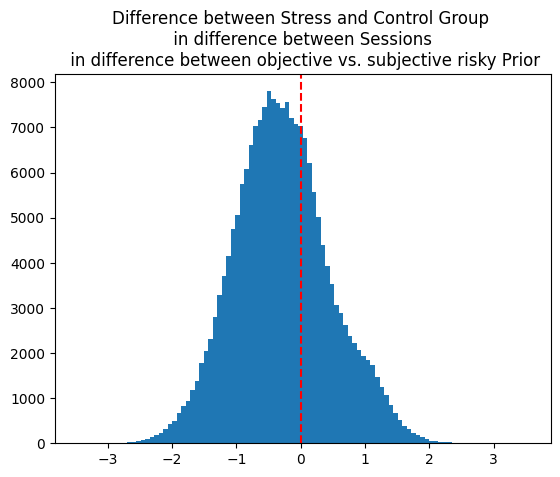

In [34]:
plt.hist(tmp, bins=100)
plt.axvline(0, color='red', linestyle='--')
plt.title('Difference between Stress and Control Group \n in difference between Sessions \n in difference between objective vs. subjective risky Prior')
print((tmp > 0).mean())

In [14]:
tmp = diff_objective_subjective.groupby(['subject','session','group']).mean()
tmp['diff_risky_obj_prior']  = np.abs(tmp['diff_risky_obj_prior'])
tmp.head()

diff_risky_obj_prior
subject session group                      
1       1       0                  0.140067
        2       0                  0.098632
2       1       0                  0.195028
        2       0                  0.199291
3       1       1                  0.782509

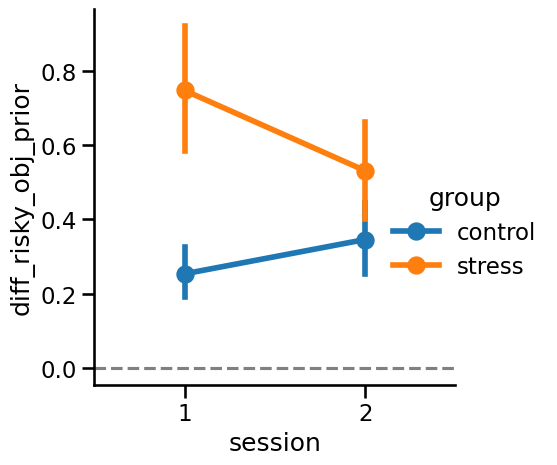

In [16]:
sns.set_context('talk')
p = sns.catplot(tmp.reset_index(),y='diff_risky_obj_prior',hue='group',x='session',kind='point')
legend_labels = {"0": "control", "1": "stress"}
for t, l in zip(p._legend.texts, legend_labels.values()):
    t.set_text(l)
#plt.ylim([-0.9, 0.1])
plt.axhline(0,  c='grey', ls='--')

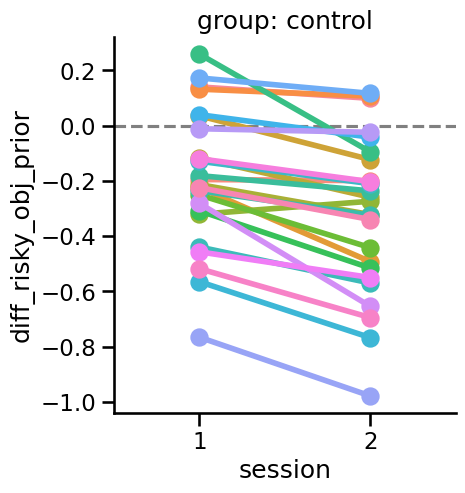

<Figure size 640x480 with 0 Axes>

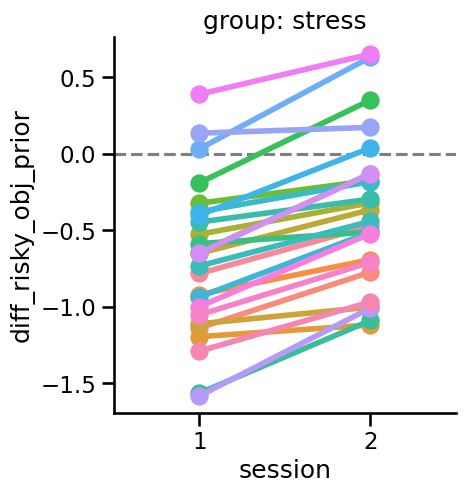

In [37]:
sns.catplot(tmp.xs(0,0,'group').reset_index(),y='diff_risky_obj_prior',hue='subject',x='session',kind='point',legend=False)
plt.title('group: control')
#plt.ylim([-0.9, 0.1])
plt.axhline(0,  c='grey', ls='--')
plt.figure()
sns.catplot(tmp.xs(1,0,'group').reset_index(),y='diff_risky_obj_prior',hue='subject',x='session',kind='point',legend=False)
plt.title('group: stress')
#plt.ylim([-0.9, 0.1])
plt.axhline(0,  c='grey', ls='--')




In [ ]:
diff_of_diff_group0 = diff_objective_subjective_ses2_group0 - diff_objective_subjective_ses1_group0
diff_of_diff_group1 = diff_objective_subjective_ses2_group1 - diff_objective_subjective_ses1_group1


sns.distplot(diff_of_diff_group0)
sns.distplot(diff_of_diff_group1)
# diff_of_diff = diff_of_diff.groupby(['chain', 'draw']).mean()
# sns.distplot(diff_of_diff)

In [36]:
final_diff = diff_of_diff_group0.groupby(['chain', 'draw']).mean() - diff_of_diff_group1.groupby(['chain', 'draw']).mean()

(final_diff > 0.0).mean()

0.0

In [ ]:
# or is there a objecive difference in risky magnitudes presented?

fac = sns.FacetGrid(df.groupby(['subject', 'group'])[['n_risky']].mean().reset_index(), hue='group', aspect=2.)

fac.map(sns.distplot, 'n_risky')
fac.add_legend()

In [38]:
n1_evidence_sd = idata.posterior['n1_evidence_sd'].to_dataframe()
n1_evidence_sd = n1_evidence_sd.join(group_mapping).set_index('group', append=True)

n1_esmu_ses1_group0 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses2_group0 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses1_group1 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('group', 0, 'n1_evidence_sd_regressors')
n1_esmu_ses2_group1 = n1_evidence_sd.xs('Intercept', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('group', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session', 0, 'n1_evidence_sd_regressors') + n1_evidence_sd.xs('session:group', 0, 'n1_evidence_sd_regressors')

n1_esmu_ses1_group0 = n1_esmu_ses1_group0.xs(0, 0, 'group')
n1_esmu_ses2_group0 = n1_esmu_ses2_group0.xs(0, 0, 'group')
n1_esmu_ses1_group1 = n1_esmu_ses1_group1.xs(1, 0, 'group')
n1_esmu_ses2_group1 = n1_esmu_ses2_group1.xs(1, 0, 'group')
n1_esmu_ses1_group0['session'] = int(1)
n1_esmu_ses2_group0['session'] = int(2)
n1_esmu_ses1_group1['session'] = int(1)
n1_esmu_ses2_group1['session'] = int(2)

df_n1_esmu = pd.concat([n1_esmu_ses1_group0.groupby(['subject']).mean(), n1_esmu_ses2_group0.groupby(['subject']).mean(), n1_esmu_ses1_group1.groupby(['subject']).mean(), n1_esmu_ses2_group1.groupby(['subject']).mean()], axis=0)
df_n1_esmu['n1_evidence_sd'] = np.exp(df_n1_esmu['n1_evidence_sd'])
df_n1_esmu['session'] = df_n1_esmu['session'].astype(int)

df_n1_esmu.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv')



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_83082/604848094.py:10: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  n1_esmu_ses1_group0['session'] = np.int(1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_83082/604848094.py:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review you